# KMeans with Log Transform

This notebook applies **log transformation** to skewed numerical features before running **KMeans clustering**.

| Step | Description |
|---|---|
| **Log Transform** | `np.log1p` compresses large value ranges and reduces skew, making distance-based algorithms more effective |
| **StandardScaler** | Normalises features to zero mean and unit variance after log transform |
| **KMeans (k=3)** | Groups products into 3 clusters based on cost and discount behaviour |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3. Data Quality Check

In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


## 4. Select & Clean Clustering Features

In [4]:
cluster_df = df[['Cost_of_the_Product', 'Discount_offered']]
cluster_df.head()

,Cost_of_the_Product,Discount_offered
0,177,44
1,216,59
2,183,48
3,176,10
4,184,46


In [5]:
cluster_df = cluster_df.dropna()

print("Shape after removing null values:", cluster_df.shape)

Shape after removing null values: (10999, 2)


## 5. Log Transformation

`np.log1p(x)` = `log(1 + x)` — safe for zero values, compresses right-skewed distributions.

In [6]:
cluster_df = cluster_df.copy()
cluster_df['Cost_log'] = np.log1p(cluster_df['Cost_of_the_Product'])
cluster_df['Discount_log'] = np.log1p(cluster_df['Discount_offered'])

cluster_df[['Cost_log', 'Discount_log']].head()

,Cost_log,Discount_log
0,5.181784,3.806662
1,5.379897,4.094345
2,5.214936,3.891820
3,5.176150,2.397895
4,5.220356,3.850148


### 5.1 Before vs After Log Transform — Distribution

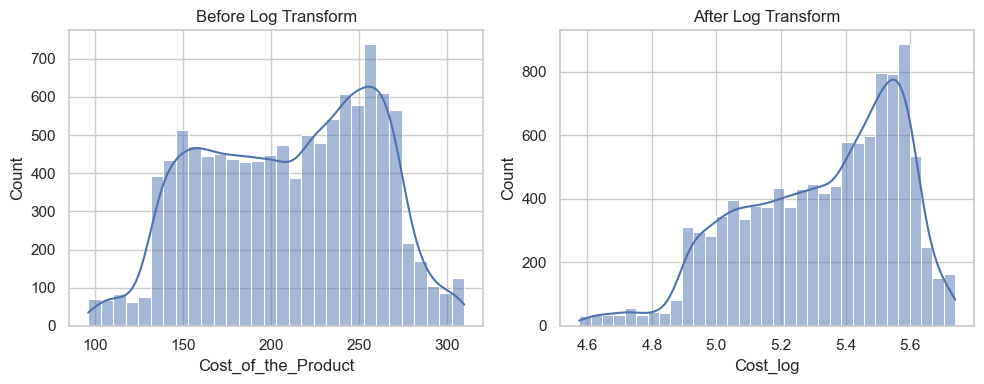

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(cluster_df['Cost_of_the_Product'], kde=True)
plt.title("Before Log Transform")

plt.subplot(1, 2, 2)
sns.histplot(cluster_df['Cost_log'], kde=True)
plt.title("After Log Transform")

plt.tight_layout()
plt.show()

## 6. Standardise & Fit KMeans

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[['Cost_log', 'Discount_log']])

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)
cluster_df['Cluster'] = clusters

cluster_df.head()

,Cost_of_the_Product,Discount_offered,Cost_log,Discount_log,Cluster
0,177,44,5.181784,3.806662,1
1,216,59,5.379897,4.094345,1
2,183,48,5.214936,3.891820,1
3,176,10,5.176150,2.397895,0
4,184,46,5.220356,3.850148,1


## 7. Cluster Profiles

In [9]:
for i in range(3):
    print("\nCluster", i)
    print(cluster_df[cluster_df['Cluster'] == i].describe())


Cluster 0
       Cost_of_the_Product  Discount_offered     Cost_log  Discount_log  \
count          3253.000000       3253.000000  3253.000000   3253.000000   
mean            159.640639          6.138026     5.068205      1.812972   
std              22.910415          3.939230     0.151293      0.572932   
min              96.000000          1.000000     4.574711      0.693147   
25%             144.000000          3.000000     4.976734      1.386294   
50%             161.000000          6.000000     5.087596      1.945910   
75%             178.000000          8.000000     5.187386      2.197225   
max             197.000000         32.000000     5.288267      3.496508   

       Cluster  
count   3253.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  

Cluster 1
       Cost_of_the_Product  Discount_offered     Cost_log  Discount_log  \
count          2274.000000       2274.000000  2274.000000   2274.000000   

## 8. Visualise Cluster Distributions

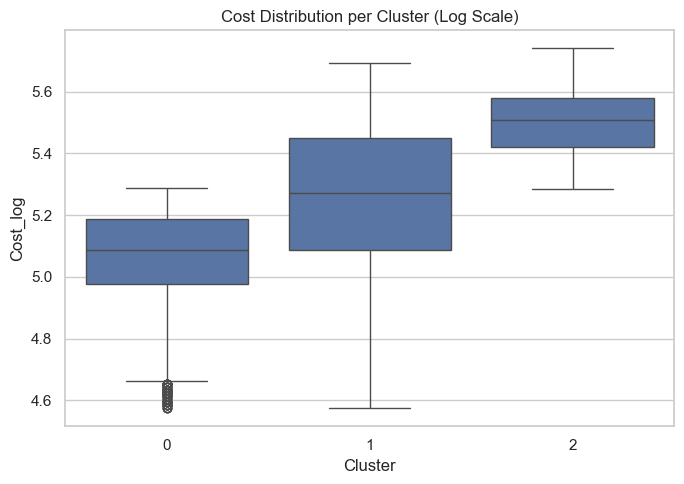

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Cluster', y='Cost_log', data=cluster_df)
plt.title("Cost Distribution per Cluster (Log Scale)")
plt.tight_layout()
plt.show()

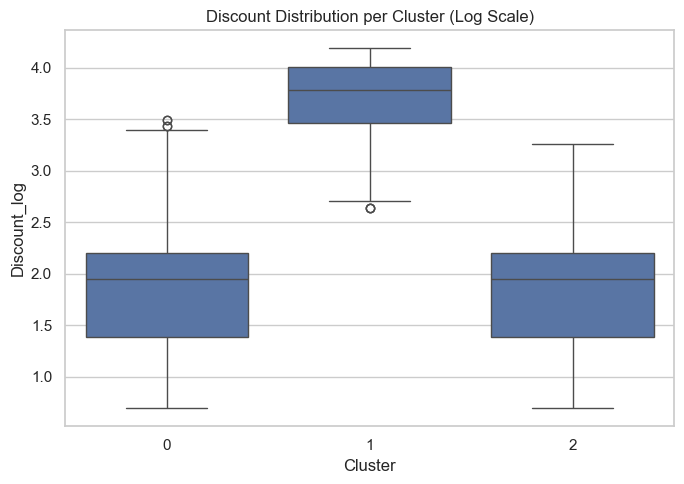

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Cluster', y='Discount_log', data=cluster_df)
plt.title("Discount Distribution per Cluster (Log Scale)")
plt.tight_layout()
plt.show()

## 9. Cluster Centers (Standardised Space)

In [12]:
print("Cluster Centers:\n")
print(kmeans.cluster_centers_)

Cluster Centers:

[[-1.05309293 -0.40360714]
 [-0.24969443  1.62237477]
 [ 0.73256672 -0.43394791]]
